In [1]:
"""
Exercise 4: NumPy Array Operations
Complete the following tasks using NumPy.
"""
import numpy as np

# Task 1: Create a 5x5 matrix where border elements are 1 and interior is 0
# (5 points)
# TODO: Create the matrix described above
# Hint: Use np.ones and array slicing

# Creating arrays
arr1 = np.ones((5,5))
arr1[1:4, 1:4] =0 # Rows 0-4, cols 1-3 assigned 0
print(arr1)
# Task 2: Normalize a random array
# (5 points)
# TODO: Normalize each column to have mean=0 and std=1
np.random.seed(42)
random_data = np.random.randn(100, 3)
normalized = (random_data - random_data.mean(axis=0)) / random_data.std(axis=0)


# Task 3: Implement linear regression solution using normal equation
# (10 points)
# Given X (features) and y (target), compute theta
# theta = (X^T X)^(-1) X^T y
X = np.random.randn(50, 3)
true_theta = np.array([2.5, -1.2, 3.7])#estimated coefficients
y = X @ true_theta + np.random.randn(50) * 0.1
# TODO: Calculate theta_hat using the normal equation
theta_hat = np.linalg.solve(X.T @ X, X.T @ y)#put theta formulma in the solve function, linear regression on point a and point b (x.t is transpose of x)
print("Estimated coefficients:", theta_hat)

# TODO: Print the estimated coefficients and compare with true_theta 
print("True coefficients:", true_theta)

[[1. 1. 1. 1. 1.]
 [1. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1.]
 [1. 1. 1. 1. 1.]]
Estimated coefficients: [ 2.51723721 -1.19783796  3.72399266]
True coefficients: [ 2.5 -1.2  3.7]


In [3]:
"""
Exercise 5: Pandas Data Analysis
Analyze a dataset of student performance.
"""

import pandas as pd
import numpy as np

# Create sample dataset
np.random.seed(42)
n_students = 200

data = {
    'student_id': range(1000, 1000 + n_students),
    'major': np.random.choice(['CS', 'Math', 'Physics', 'Biology'], n_students),
    'year': np.random.choice([1, 2, 3, 4], n_students),
    'exam_score': np.random.normal(75, 10, n_students).clip(0, 100),
    'assignments_completed': np.random.randint(0, 11, n_students),
    'hours_studied': np.random.normal(15, 5, n_students).clip(1, 40)
}

df = pd.DataFrame(data)

# Introduce some NaN values
df.loc[np.random.choice(n_students, 10), 'exam_score'] = np.nan
df.loc[np.random.choice(n_students, 5), 'hours_studied'] = np.nan

# Task 1: Data Cleaning and Exploration (10 points)
# TODO: Display basic information about the dataset
print('description')
print(df.describe())

print("colum names: ")
print(df.columns)

print("Data Types:")
print(df.dtypes)

print("First 7 rows")
print(df.head(7))

print("last 10 rows")
print(df.tail(10))
# TODO: Identify and count missing values
missingval=df.isnull().sum()
# TODO: Fill missing exam_score with the mean score for the student's major
df['exam_score'].fillna(df['exam_score'].mean())
# TODO: Fill missing hours_studied with the median for the student's year
df['hours_studied'].fillna(df['hours_studied'].median())

# Task 2: Analysis (10 points)
# TODO: Calculate and display the average exam_score by major
cs=df.loc[df['major']=='CS','exam_score']
math = df.loc[df['major'] == 'Math', 'exam_score']
physics = df.loc[df['major'] == "Physics", 'exam_score']
biology = df.loc[df['major'] == 'Biology', 'exam_score']

cs_avrgscore=round(cs.mean(),2)
print('Average CS score to 2 d.p.: ')
print(cs_avrgscore)

math_avrgscore = round(math.mean(),2)
print("Average Math score: ")
print(math_avrgscore)

physics_avrgscore = round(physics.mean(),2)
print("Average Physics score to 2 d.p.: ")
print(physics_avrgscore)

biology_avrgscore = round(biology.mean(),2)
print("Average Biology score to 2 d.p.: ")
print(biology_avrgscore)

# TODO: Find the major with the highest average exam_score
course_score={
    'major':['CS', 'Math', 'Physics', 'Biology'],
    'Average_score':[cs_avrgscore,math_avrgscore,physics_avrgscore,biology_avrgscore]
}# creates a dictionary with major and average score

c_df=pd.DataFrame(course_score) #change to. data frame
c_df_sorted=c_df.sort_values('Average_score',ascending=False)#orders majors from highest to lowest
print("Major with the highest score")
print(c_df_sorted.iat[0, 0])#selects the major with the highest score and displays

# TODO: Calculate the correlation between hours_studied and exam_score

# TODO: Create a new column 'performance' with categories:
#       'Excellent' (>90), 'Good' (80-90), 'Average' (70-80), 'Needs Improvement' (<70)
bins=[0,70,80,90,100]# sets categories from 0-70, 70-80, 80-90 and 90-100 
label=['Needs Improvement','Average', 'Good', 'Excellent']# its respective categories
df['Performance']=pd.cut(df['exam_score'],bins=bins,labels=label) # uses the cut unction to categorize the exam scores based on the bins and giving its respective label
# Task 3: Advanced Analysis (10 points)
# TODO: For each major and year combination, calculate:
#       - Number of students
#       - Average exam score
#       - Average hours studied
cs1_count = df[(df["major"] =='CS') & (df["year"] ==1)].count()
cs1_mean_score = df.loc[(df["major"] == "CS") & (df["year"] == 1),'exam_score'].mean()
cs1_mean_hours_studied = df.loc[(df["major"] == "CS") & (df["year"] == 1), "hours_studied"].mean()

cs2_count = df[(df["major"] == "CS") & (df["year"] == 2)].count()
cs2_mean_score = df.loc[(df["major"] == "CS") & (df["year"] == 2), "exam_score"].mean()
cs2_mean_hours_studied = df.loc[(df["major"] == "CS") & (df["year"] == 2), "hours_studied"].mean()

cs3_count = df[(df["major"] == "CS") & (df["year"] == 3)].count()
cs3_mean_score = df.loc[(df["major"] == "CS") & (df["year"] == 3), "exam_score"].mean()
cs3_mean_hours_studied = df.loc[(df["major"] == "CS") & (df["year"] == 3), "hours_studied"].mean()

cs4_count = df[(df["major"] == "CS") & (df["year"] == 4)].count()
cs4_mean_score = df.loc[(df["major"] == "CS") & (df["year"] == 4), "exam_score"].mean()
cs4_mean_hours_studied = df.loc[(df["major"] == "CS") & (df["year"] == 4), "hours_studied"].mean()

math1_count = df[(df["major"] == "Math") & (df["year"] == 1)].count()
math1_mean_score = df.loc[(df["major"] == "Math") & (df["year"] == 1), "exam_score"].mean()
math1_mean_hours_studied = df.loc[(df["major"] == "Math") & (df["year"] == 1), "hours_studied"].mean()

math2_count = df[(df["major"] == "Math") & (df["year"] == 2)].count()
math2_mean_score = df.loc[(df["major"] == "Math") & (df["year"] == 2), "exam_score"].mean()
math2_mean_hours_studied = df.loc[(df["major"] == "Math") & (df["year"] == 2), "hours_studied"].mean()

math3_count = df[(df["major"] == "Math") & (df["year"] == 3)].count()
math3_mean_score = df.loc[(df["major"] == "Math") & (df["year"] == 3), "exam_score"].mean()
math3_mean_hours_studied = df.loc[(df["major"] == "Math") & (df["year"] == 3), "hours_studied"].mean()

math4_count = df[(df["major"] == "Math") & (df["year"] == 4)].count()
math4_mean_score = df.loc[(df["major"] == "Math") & (df["year"] == 4), "exam_score"].mean()
math4_mean_hours_studied = df.loc[(df["major"] == "Math") & (df["year"] == 4), "hours_studied"].mean()

physics1_count = df[(df["major"] == "Physics") & (df["year"] == 1)].count()
physics1_mean_score = df.loc[(df["major"] == "Physics") & (df["year"] == 1), "exam_score"].mean()
physics1_mean_hours_studied = df.loc[(df["major"] == "Physics") & (df["year"] == 1), "hours_studied"].mean()

physics2_count = df[(df["major"] == "Physics") & (df["year"] == 2)].count()
physics2_mean_score = df.loc[(df["major"] == "Physics") & (df["year"] == 2), "exam_score"].mean()
physics2_mean_hours_studied = df.loc[(df["major"] == "Physics") & (df["year"] == 2), "hours_studied"].mean()

physics3_count = df[(df["major"] == "Physics") & (df["year"] == 3)].count()
physics3_mean_score = df.loc[(df["major"] == "Physics") & (df["year"] == 3), "exam_score"].mean()
physics3_mean_hours_studied = df.loc[(df["major"] == "Physics") & (df["year"] == 3), "hours_studied"].mean()

physics4_count = df[(df["major"] == "Physics") & (df["year"] == 4)].count()
physics4_mean_score = df.loc[(df["major"] == "Physics") & (df["year"] == 4), "exam_score"].mean()
physics4_mean_hours_studied = df.loc[(df["major"] == "Physics") & (df["year"] == 4), "hours_studied"].mean()

biology1_count = df[(df["major"] == "Biology") & (df["year"] == 1)].count()
biology1_mean_score = df.loc[(df["major"] == "Biology") & (df["year"] == 1), "exam_score"].mean()
biology1_mean_hours_studied = df.loc[(df["major"] == "Biology") & (df["year"] == 1), "hours_studied"].mean()

biology2_count = df[(df["major"] == "Biology") & (df["year"] == 2)].count()
biology2_mean_score = df.loc[(df["major"] == "Biology") & (df["year"] == 2), "exam_score"].mean()
biology2_mean_hours_studied = df.loc[(df["major"] == "Biology") & (df["year"] == 2), "hours_studied"].mean()

biology3_count = df[(df["major"] == "Biology") & (df["year"] == 3)].count()
biology3_mean_score = df.loc[(df["major"] == "Biology") & (df["year"] == 3), "exam_score"].mean()
biology3_mean_hours_studied = df.loc[(df["major"] == "Biology") & (df["year"] == 3), "hours_studied"].mean()

biology4_count = df[(df["major"] == "Biology") & (df["year"] == 4)].count()
biology4_mean_score = df.loc[(df["major"] == "Biology") & (df["year"] == 4), "exam_score"].mean()
biology4_mean_hours_studied = df.loc[(df["major"] == "Biology") & (df["year"] == 4), "hours_studied"].mean()

# faster method-df.groupby(['major', 'year'])['score'].mean() for average score
# df.groupby(['major', 'year']).count()-for number of students
# df.groupby(['major', 'year'])['hours_studied'].mean()- average hours studied

# TODO: Identify top 5 students based on exam_score (handle ties appropriately)
df_sorted=df.sort_values('exam_score', ascending=False)# sorts them by exam score in descending order
print("Top 5 students")
print(df_sorted["student_id"].head(5).to_string(index=False))# prints the name without the index

# TODO: Create a pivot table showing average exam_score by major (rows) and year (columns)

pivot_table = df.pivot_table(
    index="major",
    columns="year",
    values="exam_score",
    aggfunc={"exam_score": "mean"},
    margins=True,
    margins_name='Average'
)# creates a pivot table with means in the margins for year and for major
print(pivot_table)

description
        student_id        year  exam_score  assignments_completed  \
count   200.000000  200.000000  190.000000             200.000000   
mean   1099.500000    2.615000   75.510638               4.700000   
std      57.879185    1.159091    9.582797               3.239207   
min    1000.000000    1.000000   42.587327               0.000000   
25%    1049.750000    2.000000   68.206910               2.000000   
50%    1099.500000    3.000000   75.728033               4.000000   
75%    1149.250000    4.000000   81.813642               8.000000   
max    1199.000000    4.000000  100.000000              10.000000   

       hours_studied  
count     195.000000  
mean       14.776761  
std         5.251905  
min         1.295226  
25%        11.637963  
50%        14.575456  
75%        18.345691  
max        28.918887  
colum names: 
Index(['student_id', 'major', 'year', 'exam_score', 'assignments_completed',
       'hours_studied'],
      dtype='object')
Data Types:
student_i

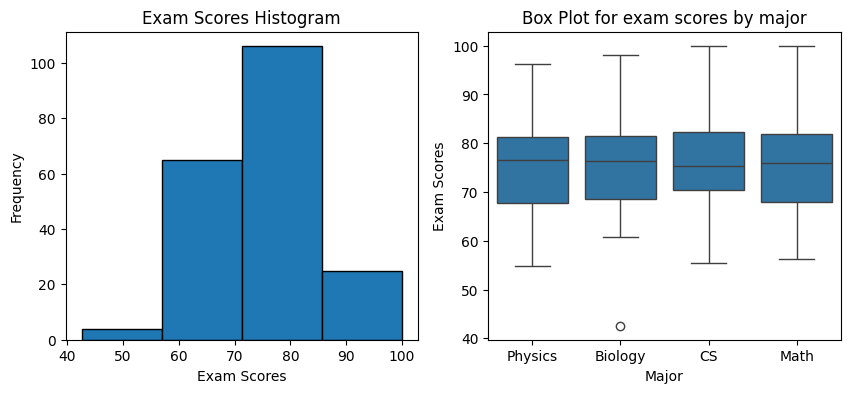

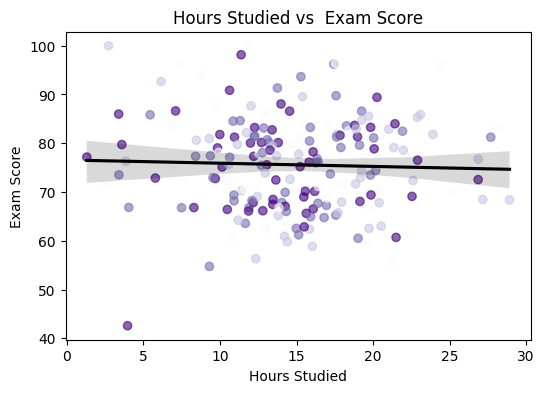

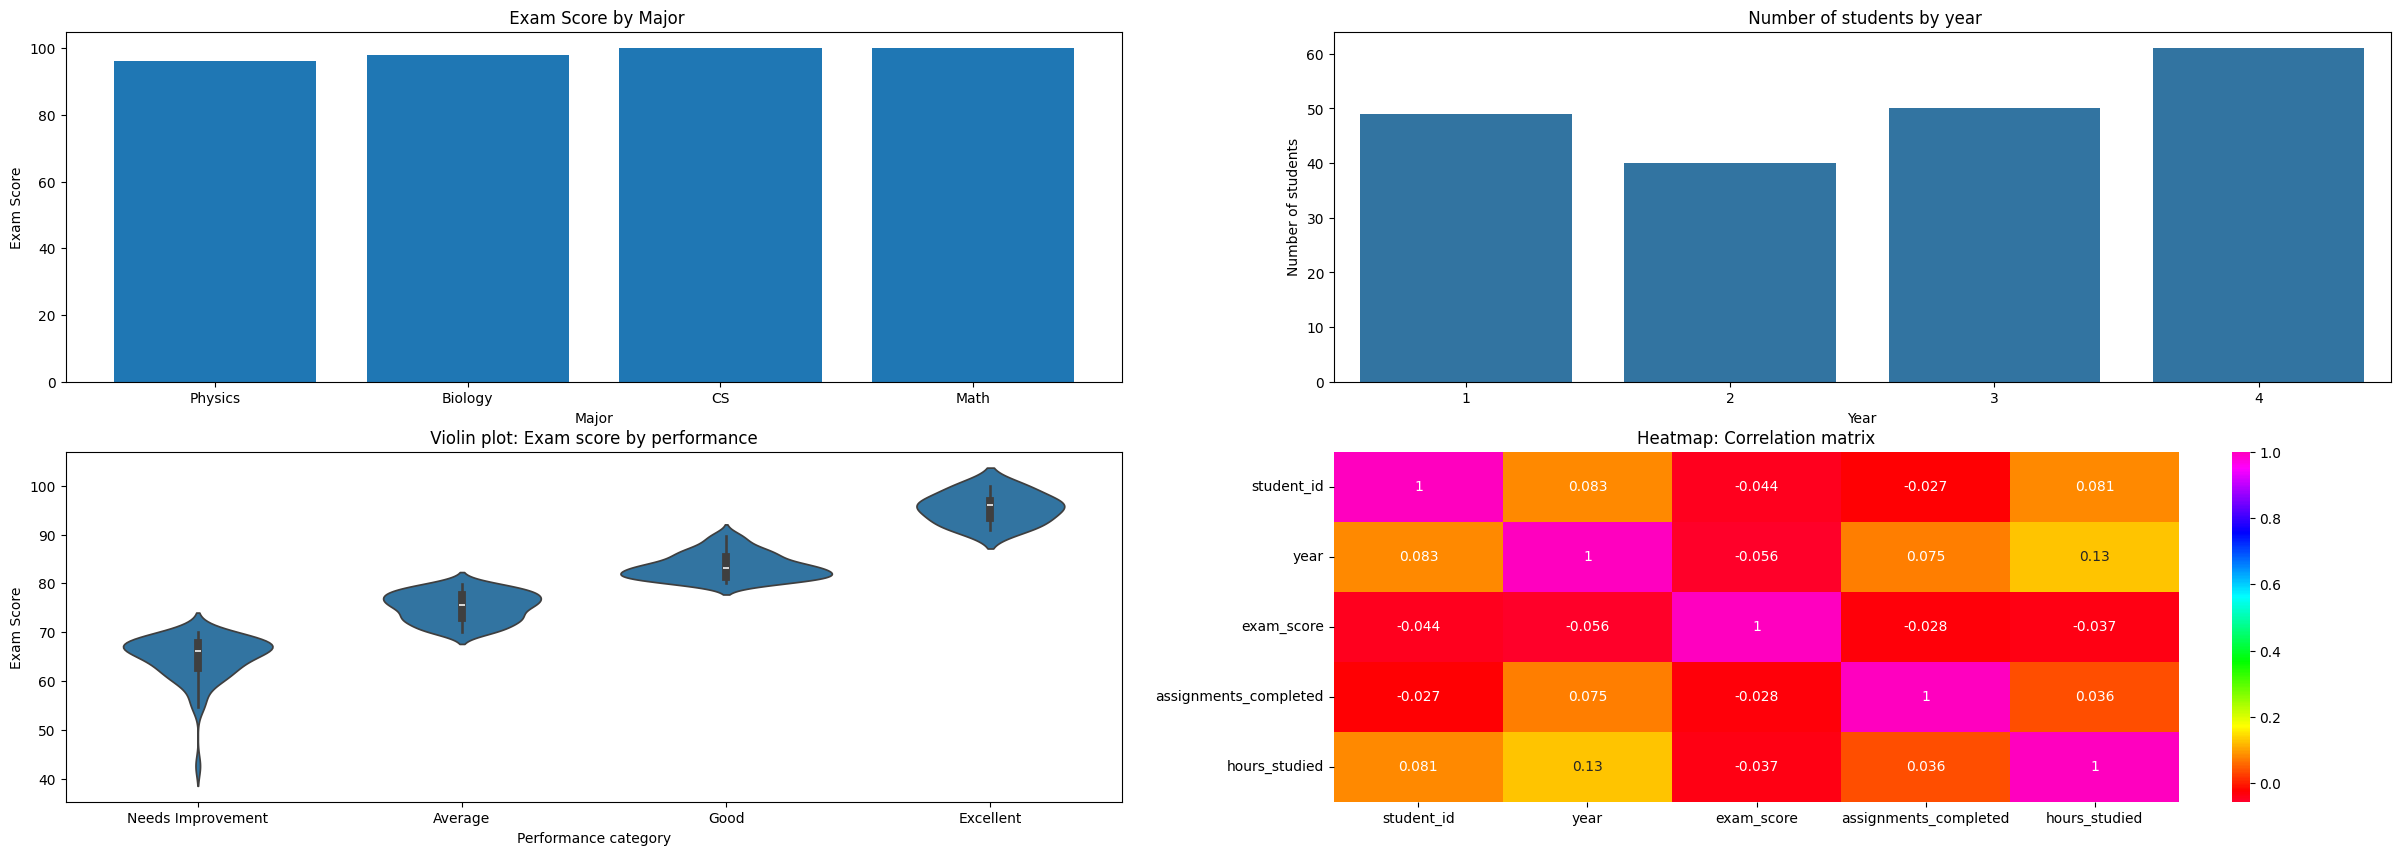

In [4]:
"""
Exercise 6: Data Visualization
Create meaningful visualizations using the dataset from Exercise 5.
"""
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Continue using the df from Exercise 5
np.random.seed(42)
n_students = 200

data = {
    "student_id": range(1000, 1000 + n_students),
    "major": np.random.choice(["CS", "Math", "Physics", "Biology"], n_students),
    "year": np.random.choice([1, 2, 3, 4], n_students),
    "exam_score": np.random.normal(75, 10, n_students).clip(0, 100),
    "assignments_completed": np.random.randint(0, 11, n_students),
    "hours_studied": np.random.normal(15, 5, n_students).clip(1, 40),
}

df = pd.DataFrame(data)
bins = [0, 70, 80, 90, 100]  # sets categories from 0-70, 70-80, 80-90 and 90-100
label = [
    "Needs Improvement",
    "Average",
    "Good",
    "Excellent",
]  # its respective categories
df["performance"] = pd.cut(
    df["exam_score"], bins=bins, labels=label
)  # uses the cut function to categorize the exam scores based on the bins and giving its respective label

# Task 1: Distribution Visualization (8 points)
# TODO: Create a figure with 2 subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))#side by side figure
#       Left: Histogram of exam scores with KDE overlay
ax1.hist(df["exam_score"], bins=4, edgecolor="black")#creates a histogram
#       Right: Box plot of exam scores by major
sns.boxplot(x="major", y="exam_score", data=df, ax=ax2)
# TODO: Add appropriate titles, labels, and styling
ax1.set_title('Exam Scores Histogram')
ax1.set_xlabel('Exam Scores')
ax1.set_ylabel('Frequency')

ax2.set_title('Box Plot for exam scores by major')
ax2.set_xlabel('Major')
ax2.set_ylabel('Exam Scores')
plt.show()
# Task 2: Relationship Visualization (8 points)
# TODO: Create a scatter plot of hours_studied vs exam_score
# TODO: Color points by major
# TODO: Add a regression line
# TODO: Include appropriate legends, titles, and axis labels
plt.figure(figsize=(6, 4))
plt.scatter(
    df["hours_studied"], 
    df["exam_score"], 
    alpha=0.6, 
    c=[{"CS": 0, "Math": 1, "Physics": 2, "Biology": 3}[major] for major in df["major"]],
    cmap="Purples"
)# c maps each major to a number then calls a color map object called viridis
sns.regplot(data=df,
   x="hours_studied",
    y="exam_score",
    color='black',
    scatter=False
)# x-axis: hours studied, y-axis:exam score
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.title("Hours Studied vs  Exam Score")
plt.show()

# Task 3: Advanced Dashboard (9 points)
# TODO: Create a 2x2 subplot figure containing:
#       1. Bar chart: Average exam score by major
#       2. Count plot: Number of students by year
#       3. Heat map: Correlation matrix of numerical columns
#       4. Violin plot: Exam score distribution by performance category
fig, axes = plt.subplots(2,2, figsize=(30,10))# creates a 2 by 2 subplot
axes[0,0].bar(df["major"],df['exam_score'])#top left
axes[0, 0].set_xlabel("Major")
axes[0, 0].set_ylabel("Exam Score")
axes[0, 0].set_title(" Exam Score by Major")

sns.countplot(data=df, x="year", ax=axes[0, 1])# creates countplot 
axes[0, 1].set_xlabel("Year")#top right
axes[0, 1].set_ylabel("Number of students")
axes[0, 1].set_title(" Number of students by year")

correlation=df.corr(numeric_only=True)
sns.heatmap(
    correlation,
    annot=True,
    cmap="gist_rainbow",
    ax=axes[1, 1],
)
axes[1, 1].set_title("Heatmap: Correlation matrix")#bottom right
#plt.yticks(rotation=-35) 

sns.violinplot(data=df, x="performance", y="exam_score",  ax=axes[1,0])
axes[1,0].set_ylabel('Exam Score')#bottom left
axes[1, 0].set_xlabel("Performance category")
axes[1, 0].set_title(" Violin plot: Exam score by performance ")
# TODO: Adjust layout, add titles, and ensure readability
plt.show()


In [ ]:
"""
Exercise 7: Integration Challenge
Combine NumPy, Pandas, and Matplotlib to solve a mini data science problem.
"""
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scenario: You're analyzing customer data for an e-commerce company.
# Generate synthetic data and provide insights.

np.random.seed(42)
n_customers = 500

# Generate customer data
ages = np.random.randint(18, 70, n_customers)
income = np.random.normal(50000, 20000, n_customers).clip(15000, 150000)
purchase_freq = np.random.poisson(5, n_customers)
avg_purchase_value = np.random.normal(100, 30, n_customers).clip(10, 500)

# Create DataFrame
customers = pd.DataFrame(
    {
        "age": ages,
        "income": income,
        "purchase_frequency": purchase_freq,
        "avg_purchase_value": avg_purchase_value,
    }
)

# TODO: Calculate customer lifetime value (CLV)
#       CLV = purchase_frequency * avg_purchase_value * (1 + churn_risk)
#       where churn_risk = 1 - (purchase_frequency / max_frequency)
max_frequency=customers['purchase_frequency'].max()
purchase_frequency=customers["purchase_frequency"]
avg_purchase_value=customers['avg_purchase_value']
churn_risk = 1 - (purchase_frequency / max_frequency)
customers['clv']=purchase_frequency * avg_purchase_value * (1 + churn_risk)

# TODO: Create age groups: 18-25, 26-35, 36-50, 51-70
customers["age_group"] = pd.cut(
    customers["age"],
    bins=[18, 25, 35, 50, 70],
    include_lowest=True,
    labels=['18 - 25', '26 - 35', '36 - 50', '51 - 70'],
)  # sets categories from 0-70, 70-80, 80-90 and 90-100

# TODO: For each age group, calculate:
#       - Number of customers
customers.groupby(['age_group'],observed=True).count() 
#       - Average income
customers.groupby(["age_group"], observed=True)["income"].mean()
#       - Average CLV
avrgclv_agegroup=customers.groupby(["age_group"], observed=True)["clv"].mean()
#       - Total CLV
customers.groupby(["age_group"], observed=True)["clv"].sum()

# TODO: Identify top 10% of customers by CLV
customers_sorted = customers.sort_values("clv", ascending=False)
print('Top 10% of customers by CLV')
print(customers_sorted.head(50).to_string(index=False))
# TODO: Create visualizations:
#       1. Scatter plot of income vs CLV (color by age group)

plt.scatter(
    customers["income"],
    customers["clv"],
    c=[
        {"18 - 25": 0, "26 - 35": 1, "36 - 50": 2, "51 - 70": 3}[age_group]
        for age_group in customers["age_group"]
    ],
    cmap="nipy_spectral",
)
plt.xlabel("Income")
plt.ylabel("CLV")
plt.title("Income vs CLV")
plt.show()
#       2. Bar chart of average CLV by age group

avrgclv_agegroup.plot(kind="bar", xlabel='Age group', ylabel='Average CLV',title="Average CLV by Age group")
plt.show()

#       3. Correlation heatmap
correlation = customers.corr(numeric_only=True)
sns.heatmap(correlation, annot=True, cmap="pink")
# TODO: Write a brief analysis paragraph (as a markdown cell)
#       summarizing key findings and recommendations



# TODO: Write a brief analysis paragraph (as a markdown cell)
#       summarizing key findings and recommendations
The lowest correlation is between income and purchase_frequency and the highest correlation was between clv and purchase_frequency. This may be because the more often a person buys the more value they should be expected to bring to the company as the more often a person buys something there is a high chance that they really like the service being offered. The reason between the low correlation between income and purchase frequency is that a persons income does not dictate their taste.